# Handwritten Digit Classification Using Multilayer Perceptron (MLP)

This notebook details the end-to-end process of training a Neural Network to classify handwritten digits (0-9) using the MNIST dataset. Our goal is to achieve high accuracy while clearly documenting data preprocessing, model architecture, and comprehensive evaluation metrics.

## 1. Environment Setup & Imports

Below we import the tools necessary for data manipulation, plotting, model building, and evaluation.

In [1]:
import numpy as np
%pip install pandas
%pip install seaborn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Dataset Loading (MNIST)

We load the globally recognized MNIST dataset which contains 60,000 training images and 10,000 testing images of handwritten digits.

In [2]:
# Load dataset from Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training instances: {x_train.shape[0]} images, Shape: {x_train.shape[1:]}")
print(f"Testing instances:  {x_test.shape[0]} images, Shape: {x_test.shape[1:]}")

Training instances: 60000 images, Shape: (28, 28)
Testing instances:  10000 images, Shape: (28, 28)


## 3. Visualization of Sample Images

It is highly important to understand the organic nature of our data visually before passing it into a mathematical framework. Let's look at a few examples alongside their targets.

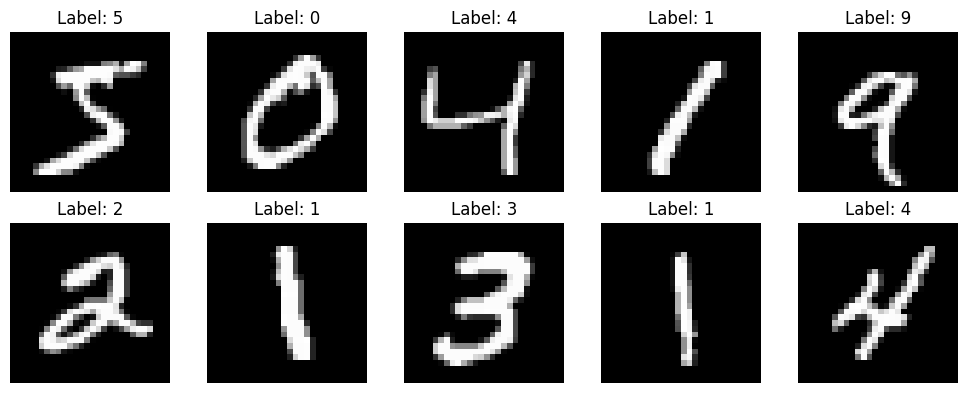

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing (Normalization)

Raw pixel values exist on a scale of `0` to `255`. To optimize Neural Network convergence, we normalize these bounds to fall strictly between `0.0` and `1.0`.

In [4]:
# Convert integers to float32 and normalize
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print(f"Max pixel value before: {np.max(x_train)}")
print(f"Max pixel value after:  {np.max(x_train_norm)}")

Max pixel value before: 255
Max pixel value after:  1.0


## 5. One-Hot Encoding

The model output uses a `softmax` activation to output probabilities for 10 distinct classes. Therefore, we convert integer labels (e.g. `2`) into categorical one-hot arrays (e.g. `[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]`).

In [5]:
num_classes = 10
y_train_encoded = keras.utils.to_categorical(y_train, num_classes)
y_test_encoded = keras.utils.to_categorical(y_test, num_classes)

print(f"Original label: {y_train[0]}")
print(f"Encoded vector: {y_train_encoded[0]}")

Original label: 5
Encoded vector: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 6. Model Building (Multilayer Perceptron)

We construct a deeper sequentially layered Multi-Layer Perceptron (MLP) with **BatchNormalization** for stable training and stronger regularization.
- **Flatten Layer:** Restructures `28x28` into a `784` 1D array.
- **Hidden Layer 1:** 512 units — Dense → BatchNorm → ReLU → Dropout(0.3)
- **Hidden Layer 2:** 256 units — Dense → BatchNorm → ReLU → Dropout(0.3)
- **Hidden Layer 3:** 128 units — Dense → BatchNorm → ReLU → Dropout(0.2)
- **Output Layer:** 10 neurons with `softmax` providing prediction confidence scores for each digit.

In [6]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28), name="Input_Flatten"),

    # Hidden Layer 1 — 512 units
    layers.Dense(512, name="Hidden_Layer_1"),
    layers.BatchNormalization(name="BN_1"),
    layers.Activation('relu', name="ReLU_1"),
    layers.Dropout(0.3, name="Dropout_1"),

    # Hidden Layer 2 — 256 units
    layers.Dense(256, name="Hidden_Layer_2"),
    layers.BatchNormalization(name="BN_2"),
    layers.Activation('relu', name="ReLU_2"),
    layers.Dropout(0.3, name="Dropout_2"),

    # Hidden Layer 3 — 128 units
    layers.Dense(128, name="Hidden_Layer_3"),
    layers.BatchNormalization(name="BN_3"),
    layers.Activation('relu', name="ReLU_3"),
    layers.Dropout(0.2, name="Dropout_3"),

    # Output
    layers.Dense(num_classes, activation='softmax', name="Output_Layer")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Parth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Flatten (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_1 (Activation)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_2 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_3 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

## 6.1 Model Visualization

The function below renders the full **784-input (28×28 pixel grid)** architecture as a dark-mode backend-style diagram, showing all four computational layers with connection lines.

C:\Users\Parth\AppData\Local\Temp\ipykernel_10372\1043976659.py:57: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y_dot), r, color=color, alpha=0.85,


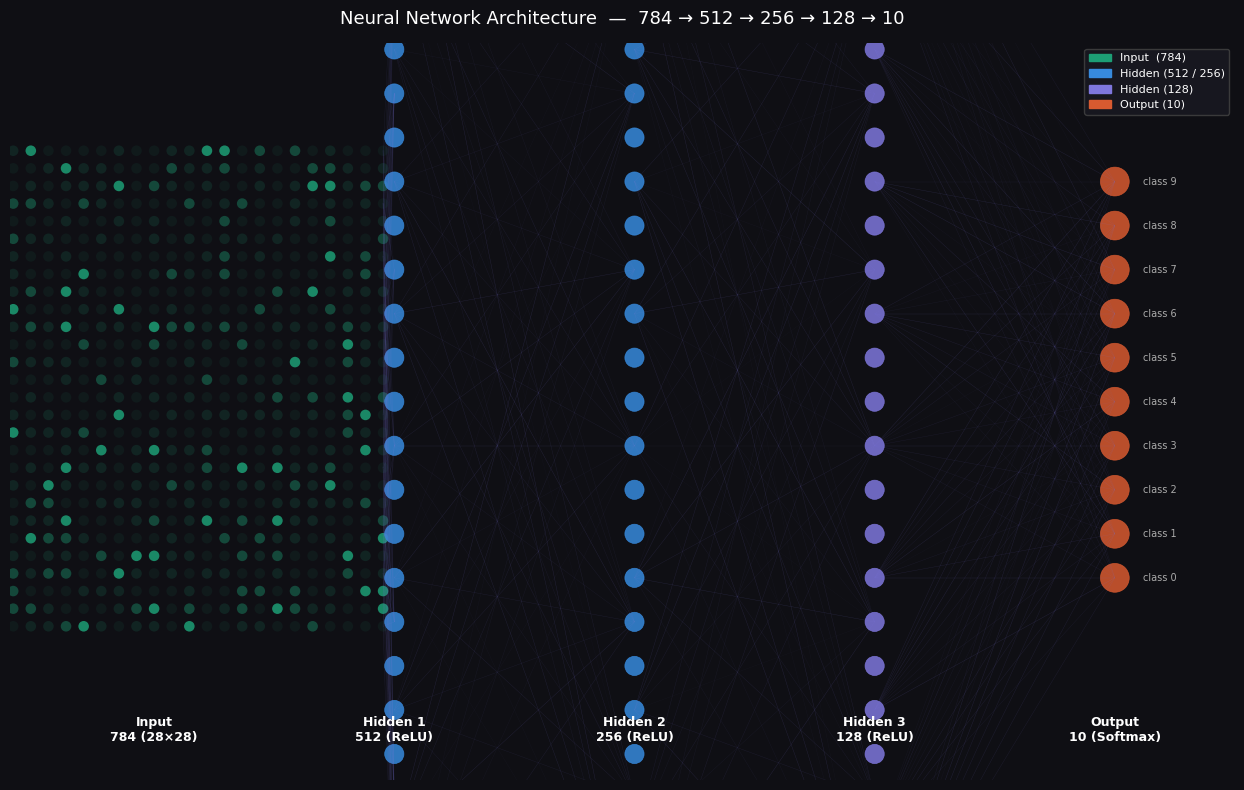

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def draw_nn_backend():
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_facecolor('#0f0f14')
    fig.patch.set_facecolor('#0f0f14')

    # ── Architecture definition ───────────────────────────────────────────
    arch = [
        {"label": "Input\n784 (28×28)",  "n": 784, "x": 1.0,  "color": "#1D9E75", "dot_grid": True},
        {"label": "Hidden 1\n512 (ReLU)", "n": 512, "x": 4.0,  "color": "#378ADD"},
        {"label": "Hidden 2\n256 (ReLU)", "n": 256, "x": 7.0,  "color": "#378ADD"},
        {"label": "Hidden 3\n128 (ReLU)", "n": 128, "x": 10.0, "color": "#7F77DD"},
        {"label": "Output\n10 (Softmax)", "n": 10,  "x": 13.0, "color": "#D85A30"},
    ]

    MAX_DOTS  = 28
    DOT_R     = 0.12
    GRID_COLS = 28
    GRID_ROWS = 28
    GRID_STEP = 0.22

    def y_positions(n, max_dots=MAX_DOTS):
        show = min(n, max_dots)
        return np.linspace(-(show - 1) / 2 * 0.55, (show - 1) / 2 * 0.55, show)

    layer_centers = []  # (x_right_edge, list_of_y)

    for layer in arch:
        x     = layer["x"]
        color = layer["color"]

        if layer.get("dot_grid"):
            # ── 28×28 pixel grid for the input layer ─────────────────────
            gx0 = x - (GRID_COLS * GRID_STEP) / 2
            gy0 = -(GRID_ROWS * GRID_STEP) / 2
            for r in range(GRID_ROWS):
                for c in range(GRID_COLS):
                    px = gx0 + c * GRID_STEP
                    py = gy0 + r * GRID_STEP
                    alpha = np.random.choice([0.08, 0.15, 0.4, 0.85],
                                             p=[0.50, 0.25, 0.15, 0.10])
                    circle = plt.Circle((px, py), DOT_R * 0.55,
                                        color=color, alpha=alpha, linewidth=0)
                    ax.add_patch(circle)
            grid_right = gx0 + (GRID_COLS - 1) * GRID_STEP
            col_ys     = np.linspace(gy0, gy0 + (GRID_ROWS - 1) * GRID_STEP, 10)
            layer_centers.append((grid_right, col_ys))
            label_x = x
        else:
            ys      = y_positions(layer["n"])
            is_last = (layer["n"] == 10)
            for y_dot in ys:
                r = DOT_R * (1.5 if is_last else 1.0)
                circle = plt.Circle((x, y_dot), r, color=color, alpha=0.85,
                                     linewidth=0.5, edgecolor='white')
                ax.add_patch(circle)
                if is_last:
                    idx = int(round((y_dot - ys[0]) / (ys[-1] - ys[0] + 1e-9) * 9))
                    ax.text(x + 0.35, y_dot, f"class {idx}",
                            color='#aaaaaa', fontsize=7, va='center')
            layer_centers.append((x, ys))
            label_x = x

        ax.text(label_x, -4.2, layer["label"],
                ha='center', va='top', color='white',
                fontsize=9, fontweight='bold')

    # ── Connection lines between every adjacent pair of layers ───────────
    for i in range(len(layer_centers) - 1):
        x1, ys1 = layer_centers[i]
        x2, ys2 = layer_centers[i + 1]
        s1 = ys1[::max(1, len(ys1) // 8)]
        s2 = ys2[::max(1, len(ys2) // 6)]
        for y1 in s1:
            for y2 in s2:
                ax.plot([x1, x2], [y1, y2],
                        color='#7F77DD',
                        linewidth=0.3,
                        alpha=np.random.uniform(0.04, 0.20))

    # ── Legend ────────────────────────────────────────────────────────────
    patches = [
        mpatches.Patch(color='#1D9E75', label='Input  (784)'),
        mpatches.Patch(color='#378ADD', label='Hidden (512 / 256)'),
        mpatches.Patch(color='#7F77DD', label='Hidden (128)'),
        mpatches.Patch(color='#D85A30', label='Output (10)'),
    ]
    ax.legend(handles=patches, loc='upper right',
              facecolor='#1a1a22', edgecolor='#444444',
              labelcolor='white', fontsize=8)

    # ── Axis / title ──────────────────────────────────────────────────────
    ax.set_xlim(-0.8, 14.5)
    ax.set_ylim(-5.0, 4.2)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(
        "Neural Network Architecture  —  784 → 512 → 256 → 128 → 10",
        color='white', fontsize=13, pad=14
    )

    plt.tight_layout()
    plt.show()

draw_nn_backend()

## 7. Training Process

We train the model over 15 Epochs using batches of 128 instances. We utilize a `validation_split` to continuously measure generalizability against unseen samples during tracking.

In [8]:
batch_size = 128
epochs = 15

print("Initiating training phase...")
history = model.fit(
    x_train_norm, y_train_encoded,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    verbose=1
)
print("Training Complete!")

Initiating training phase...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8998 - loss: 0.3388 - val_accuracy: 0.9690 - val_loss: 0.1060
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9510 - loss: 0.1569 - val_accuracy: 0.9765 - val_loss: 0.0775
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9644 - loss: 0.1154 - val_accuracy: 0.9768 - val_loss: 0.0766
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9682 - loss: 0.0994 - val_accuracy: 0.9812 - val_loss: 0.0605
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9737 - loss: 0.0823 - val_accuracy: 0.9822 - val_loss: 0.0599
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9763 - loss: 0.0761 - val_accuracy: 0.9815 - val_loss: 0.0656
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9796 - loss: 0.0637 - val_accuracy: 0.9842 - val_loss: 0.0578
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9808 - lo

## 8. Accuracy / Loss Graphs

Plotting historical Loss constraints helps us verify our model isn't under-fitting or heavily over-fitting the dataset.

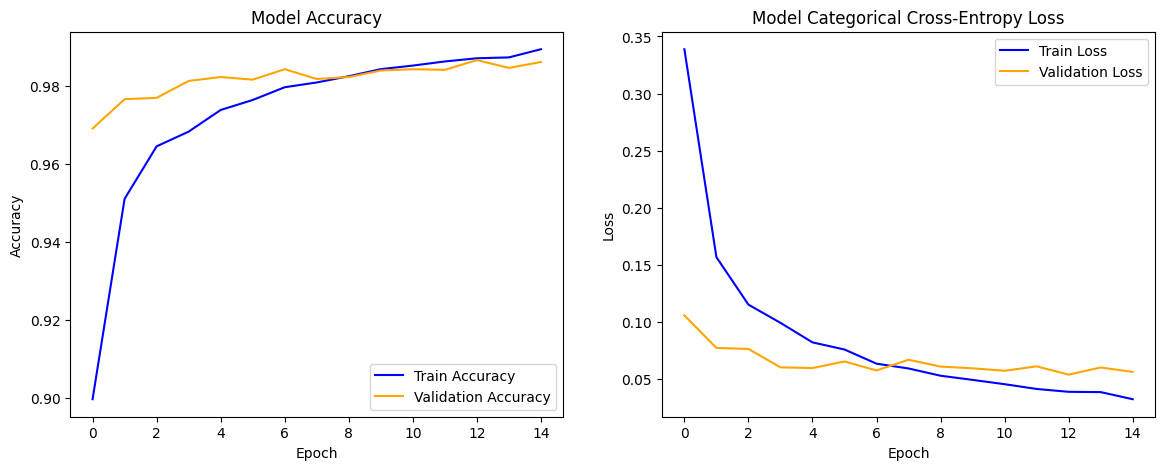

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Graph
ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='lower right')

# Loss Graph
ax[1].plot(history.history['loss'], label='Train Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax[1].set_title('Model Categorical Cross-Entropy Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='upper right')

plt.show()

## 9. Model Evaluation & Statistical Metrics

Finally, to conclusively prove the performance efficacy of our model, we run predictions on our sequestered *testing dataset* to determine precise diagnostic statistics:
- **Accuracy**: Total correct / Total Guesses.
- **Precision**: Total True Positives / Total Projected Positives.
- **Recall**: Total True Positives / Total Actual Positives.
- **F1-Score**: Harmonic Mean bridging Precision and Recall gaps.

In [10]:
# Derive probability distributions across test-set images
y_prob = model.predict(x_test_norm)
# Reduce probability vectors back down to integer class targets
y_pred = np.argmax(y_prob, axis=1)

# Scikit-Learn Metric Computations (using 'macro' averaging logic)
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')
f1        = f1_score(y_test, y_pred, average='macro')

print("="*50)
print(f"TEST ACCURACY  : {acc * 100:.2f}%")
print(f"TEST PRECISION : {precision * 100:.2f}%")
print(f"TEST RECALL    : {recall * 100:.2f}%")
print(f"TEST F1 SCORE  : {f1 * 100:.2f}%")
print("="*50)

# Detailed Report By Digit Range
print("\nClassification Report by Integer Class:")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step
TEST ACCURACY  : 98.39%
TEST PRECISION : 98.39%
TEST RECALL    : 98.37%
TEST F1 SCORE  : 98.38%

Classification Report by Integer Class:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## 10. Save Weights for Frontend Infrastructure

Assuming our stats pass academic muster, we lock in our trained parameters for the external web application to utilize for real-time inference.

In [11]:
import os
model_dir = '../backend/model'
os.makedirs(model_dir, exist_ok=True)
model.save(f'{model_dir}/digit_model.h5')
print('Model successfully saved to ../backend/model/digit_model.h5')

Model successfully saved to ../backend/model/digit_model.h5


In [12]:
import pandas as pd

layers_info = []

for layer in model.layers:
    if hasattr(layer, 'weights') and len(layer.weights) > 0:
        weights = layer.weights[0].shape
        bias    = layer.weights[1].shape

        weight_count = layer.count_params() - bias[0]
        bias_count   = bias[0]

        layers_info.append([
            layer.name,
            str(weights),
            str(bias),
            weight_count,
            bias_count,
            layer.count_params()
        ])

df = pd.DataFrame(layers_info, columns=[
    "Layer",
    "Weights Shape",
    "Bias Shape",
    "Weights Count",
    "Bias Count",
    "Total Params"
])

df

,Layer,Weights Shape,Bias Shape,Weights Count,Bias Count,Total Params
0,Hidden_Layer_1,"(784, 512)","(512,)",401408,512,401920
1,BN_1,"(512,)","(512,)",1536,512,2048
2,Hidden_Layer_2,"(512, 256)","(256,)",131072,256,131328
3,BN_2,"(256,)","(256,)",768,256,1024
4,Hidden_Layer_3,"(256, 128)","(128,)",32768,128,32896
5,BN_3,"(128,)","(128,)",384,128,512
6,Output_Layer,"(128, 10)","(10,)",1280,10,1290


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step


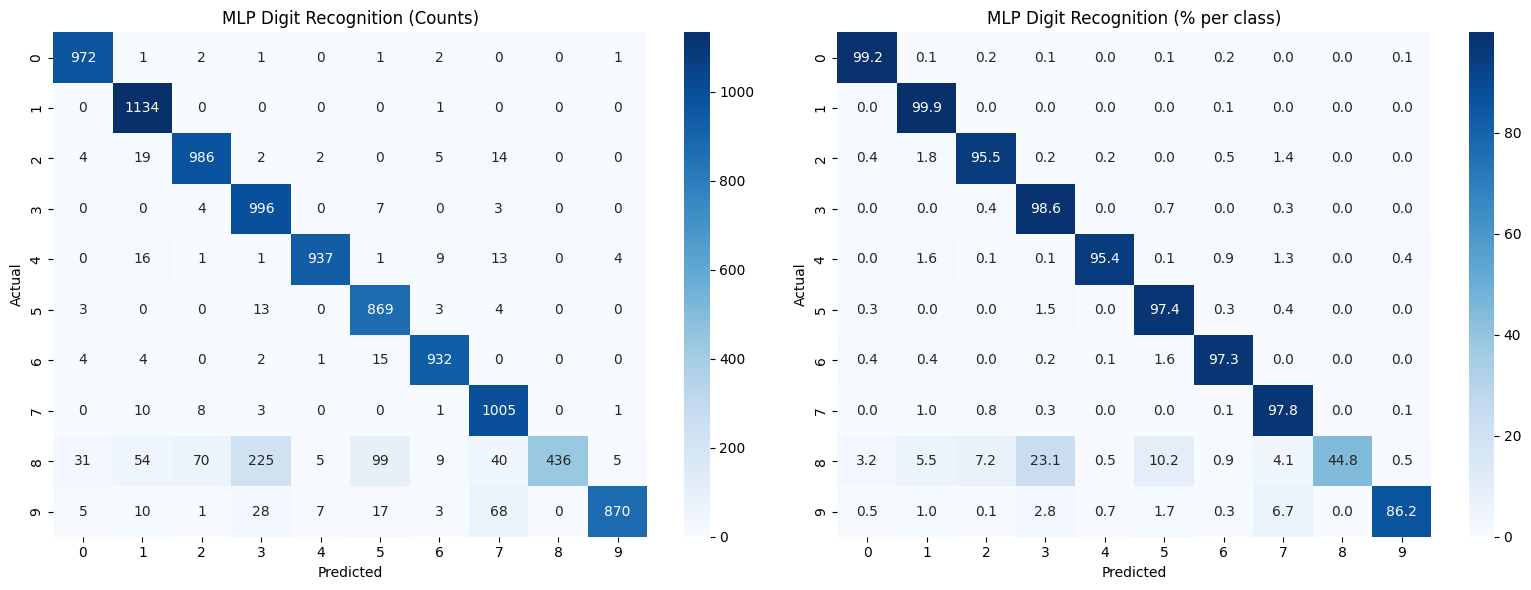

In [13]:
# Predict on test data
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test

# Confusion Matrix (counts)
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize (percentage per class)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("MLP Digit Recognition (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# RIGHT: Percentage
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set_title("MLP Digit Recognition (% per class)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 10. Dashboard Synchronization & Export

To ensure the **Neural Core** web dashboard reflects these exact metrics, we export the finalized model weights directly to the backend production directory.

In [14]:
# Finalize: Export model for the Neural Core Dashboard
import os

model_dir  = "../backend/model"
model_path = os.path.join(model_dir, "digit_model.h5")

# Ensure directory exists
os.makedirs(model_dir, exist_ok=True)

# Save current model state
model.save(model_path)
print(f"\u2705 Protocol complete. Model successfully exported to: {model_path}")

✅ Protocol complete. Model successfully exported to: ../backend/model\digit_model.h5
